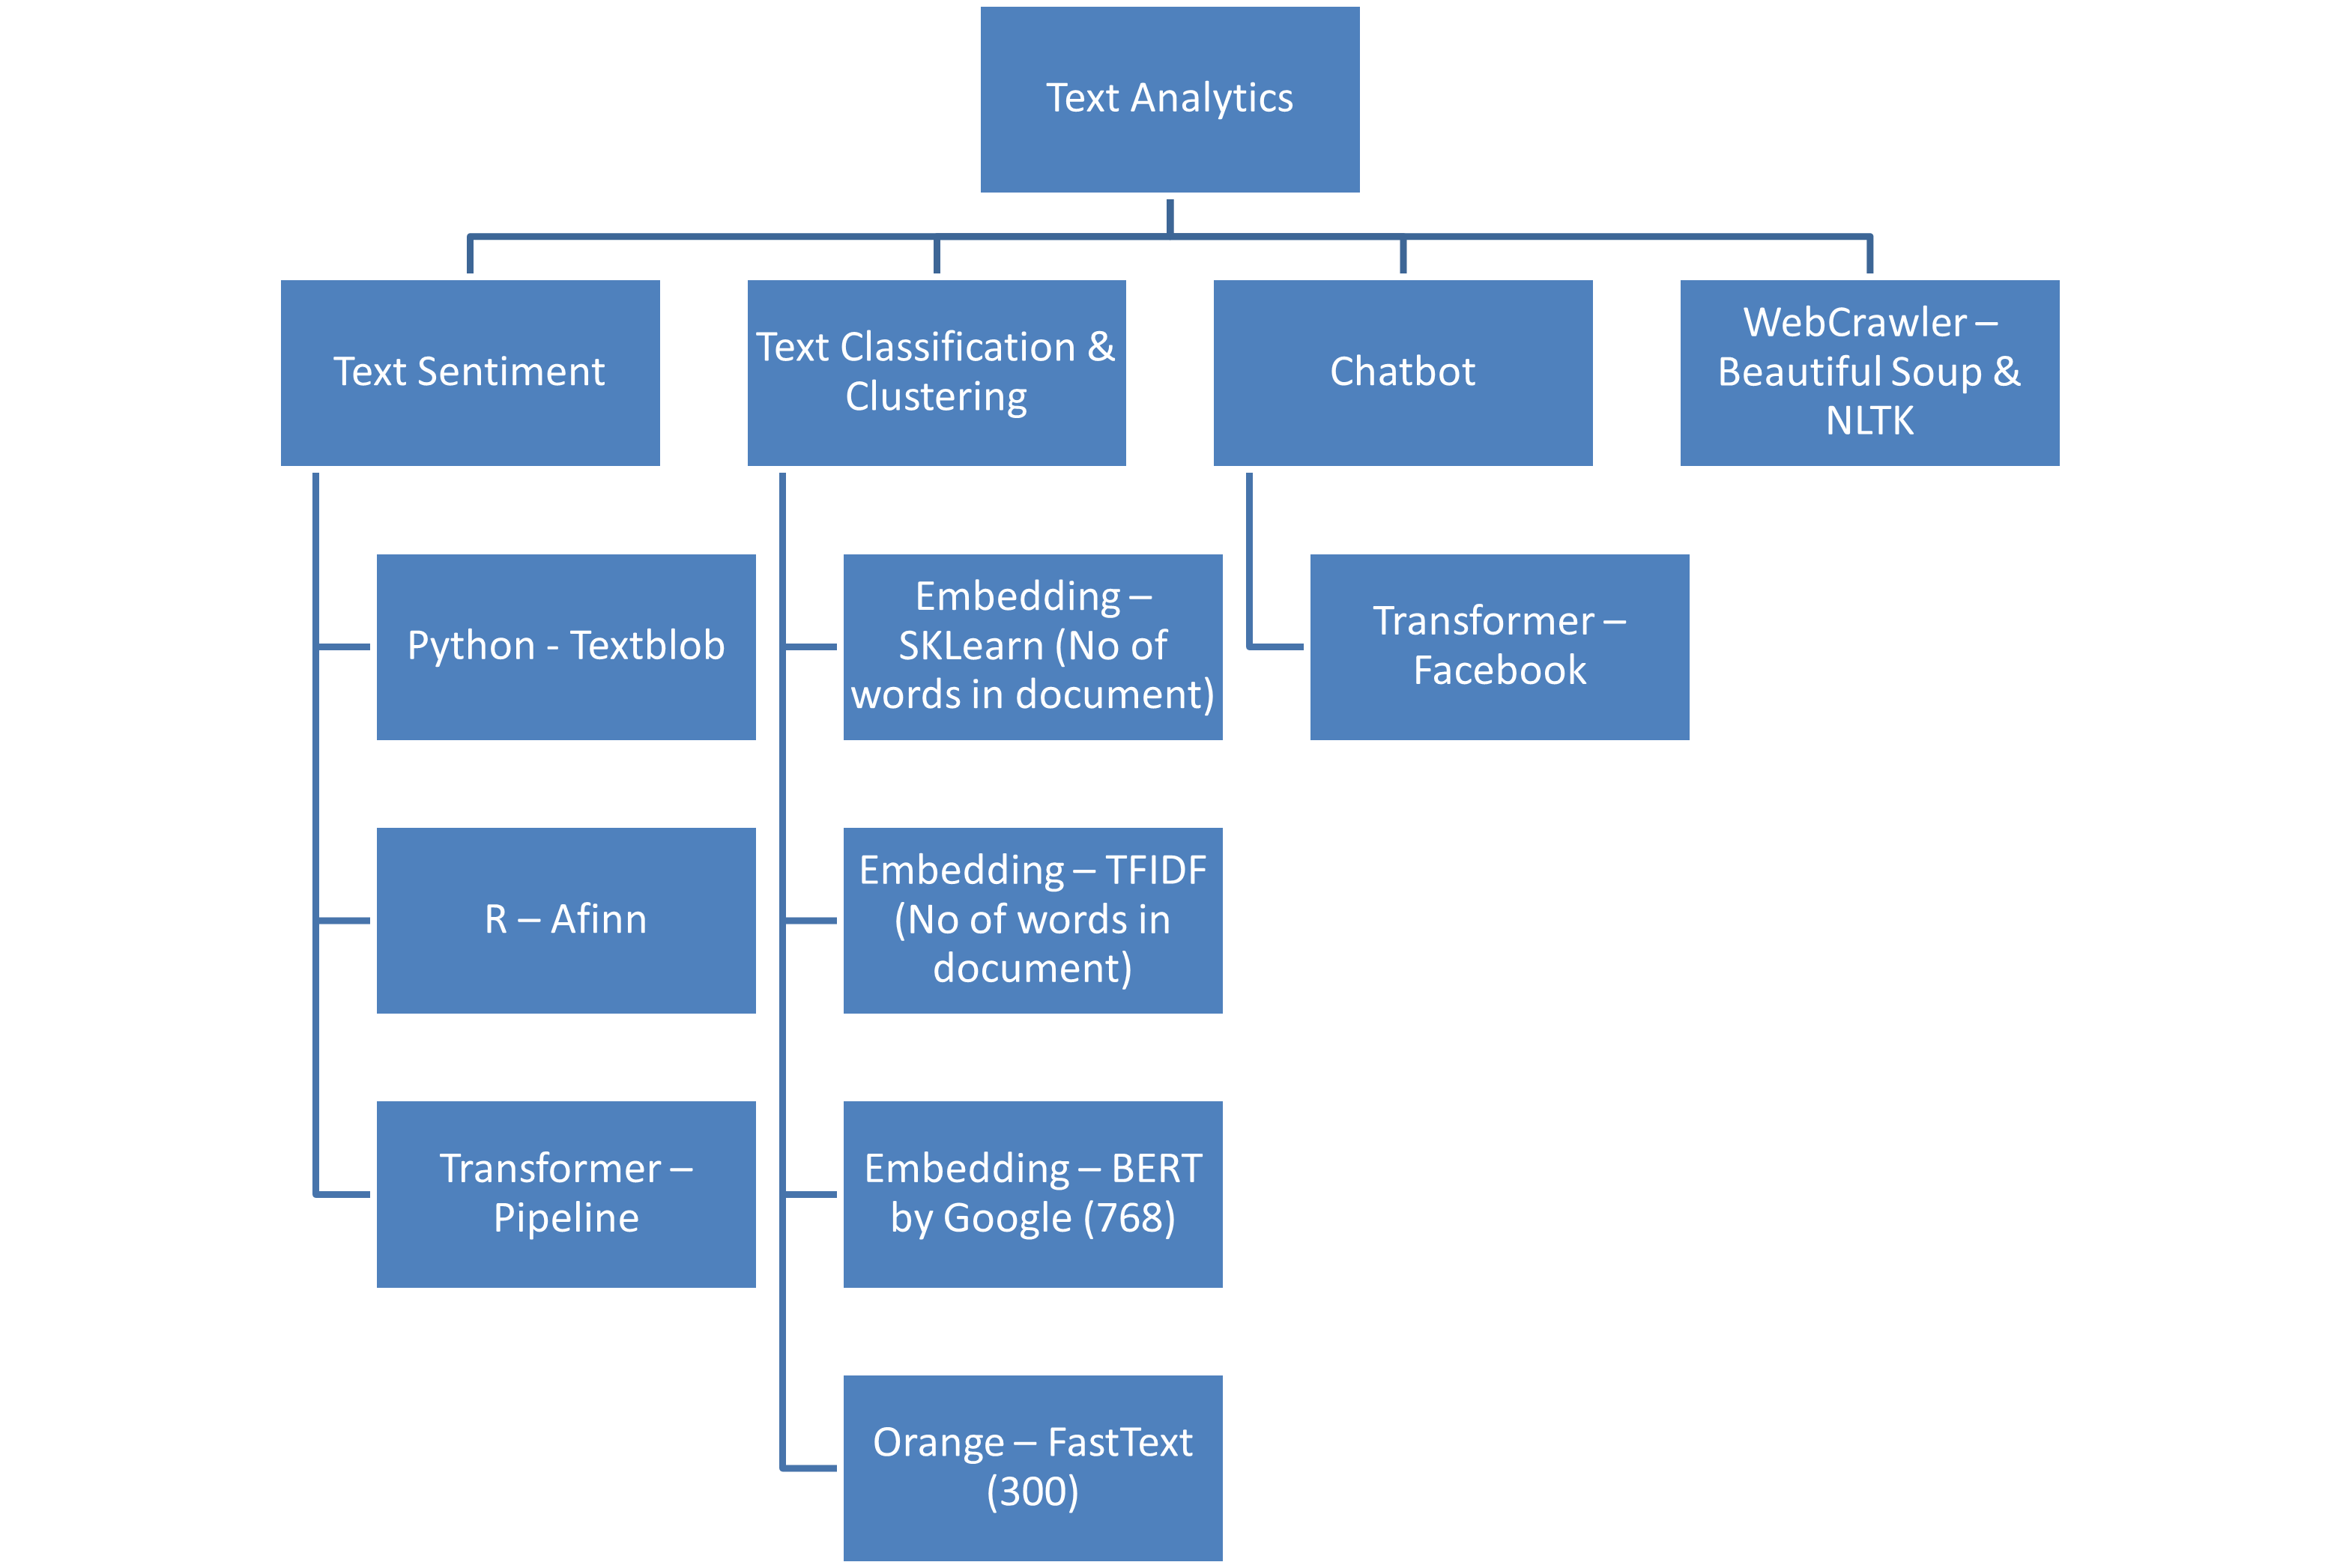

## **# Document Classification - News Classification Example**



# **CountVectorizer By SKLearn**

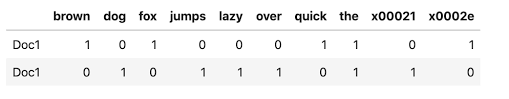

In [1]:
import pandas as pd
df = pd.read_csv("News Category (Text).csv")

X=df['headline']
Y=df['category']

from sklearn.feature_extraction.text import CountVectorizer
X_CV = CountVectorizer().fit_transform(X)

from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X_CV, Y)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

model = LogisticRegression()
model.fit(X_train, Y_train)
pred = model.predict(X_test)
cm=confusion_matrix(Y_test, pred)
print(cm)
acc=(cm[0,0]+cm[1,1])/sum(sum(cm))
print('Accuracy count vectorizer is ', acc)

[[946  18]
 [ 64 688]]
Accuracy count vectorizer is  0.9522144522144522


# **TFIDF**

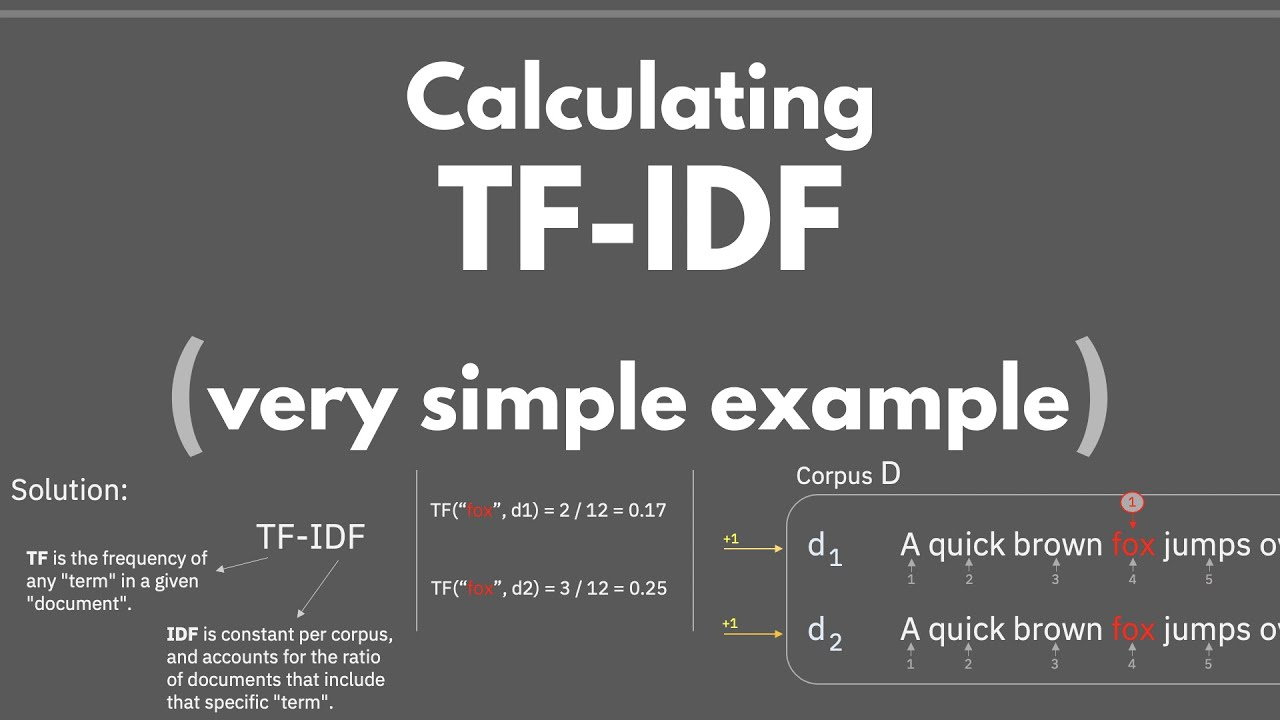

In [2]:
X

,headline
0,There Were 2 Mass Shootings In Texas Last Week...
1,Rachel Dolezal Faces Felony Charges For Welfar...
2,Trump's New 'MAGA'-Themed Swimwear Sinks On Tw...
3,Seth Meyers Has 1 Funny Regret After Trump Can...
4,Colbert Wants To Turn NYC Subway Rides Into A ...
...,...
6859,Body Of Child Found Along Highway 'Consistent'...
6860,David & Me Chronicles Rubin Carter's Fight to ...
6861,World's Dumbest Hijack Attempt?
6862,Bible Pests


In [3]:
from sklearn.feature_extraction.text import TfidfTransformer

X_train = TfidfTransformer().fit_transform(X_train)
X_test = TfidfTransformer().fit_transform(X_test)

model = LogisticRegression()
model.fit(X_train, Y_train)
pred = model.predict(X_test)
cm=confusion_matrix(Y_test, pred)
print(cm)
acc=(cm[0,0]+cm[1,1])/sum(sum(cm))
print('Accuracy with TFIDF is ',acc)

[[945  19]
 [ 79 673]]
Accuracy with TFIDF is  0.9428904428904429


## **Transformer BERT by Google**
Bidirectional Encoder Representations from Transformers



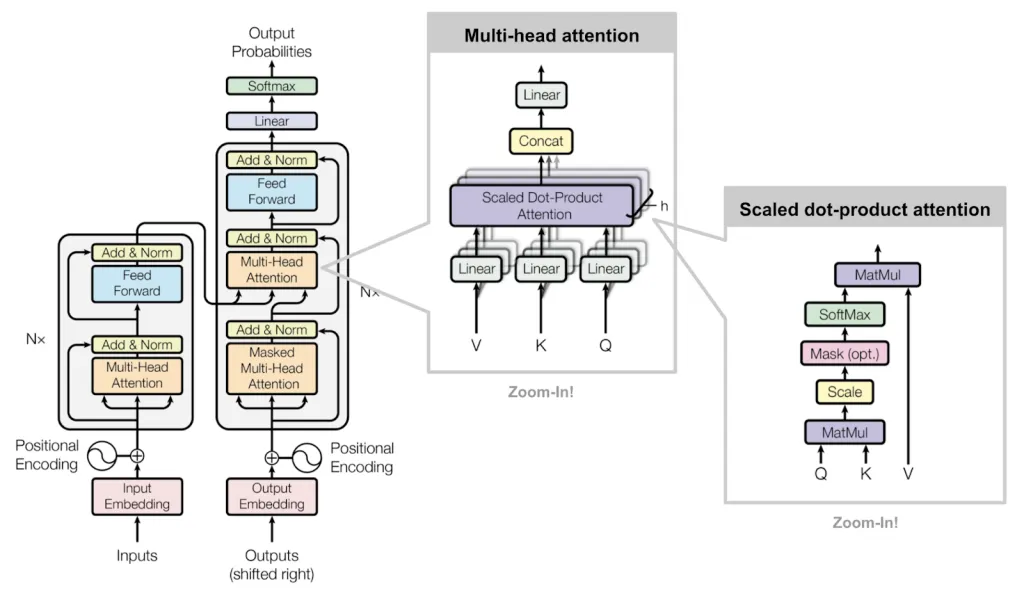

In [4]:
!pip install sentence_transformers

In [5]:
from sentence_transformers import SentenceTransformer
model = SentenceTransformer('bert-base-nli-mean-tokens')

X_bert = model.encode(X)

from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X_bert, Y)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

model = LogisticRegression()
model.fit(X_train, Y_train)
pred = model.predict(X_test)
cm=confusion_matrix(Y_test, pred)
print(cm)
acc=(cm[0,0]+cm[1,1])/sum(sum(cm))
print('Accuracy using Bert is ', acc)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

[[956  30]
 [ 33 697]]
Accuracy using Bert is  0.9632867132867133


In [6]:
import pandas as pd
df = pd.read_csv("News Category (Text).csv")

X=df['headline']
Y=df['category']

from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer()
X_CV = cv.fit_transform(X)

from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X_CV, Y)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

model = LogisticRegression()
model.fit(X_train, Y_train)
pred = model.predict(X_test)
cm=confusion_matrix(Y_test, pred)
print(cm)
acc=(cm[0,0]+cm[1,1])/sum(sum(cm))
print('Accuracy count vectorizer is ', acc)

#store model
import joblib
joblib.dump(model, 'model.pkl')
joblib.dump(cv, "vectorizer.pkl")

vectorizer = joblib.load("vectorizer.pkl")
model = joblib.load("model.pkl")

X_emb = vectorizer.transform(["murder she wrote"])
pred = model.predict(X_emb)
print(pred)

[[979  30]
 [ 54 653]]
Accuracy count vectorizer is  0.951048951048951
['CRIME']


In [7]:
import gradio as gr
import joblib


# Load model + vectorizer
model = joblib.load("model.pkl")
vectorizer = joblib.load("vectorizer.pkl")

def predict_category(text):
    X_emb = vectorizer.transform([text])
    pred = model.predict(X_emb)[0]
    return pred

demo = gr.Interface(
    fn=predict_category,
    inputs=gr.Textbox(lines=2, placeholder="Enter a headline..."),
    outputs="text",
    title="📰 News Headline Classifier",
    description="Type a news headline and get its predicted category."
)

if __name__ == "__main__":
    demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d2c99a70135f17fafb.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
